# Long Short-Term Memory (LSTM)

This project has a triple set of objectives in understanding the full Natural Language Processing (NLP) data cleaning and preprocessing pipeline, tackling a sentiment analysis task, and delving more deeply into gated, memory-based RNN architectures and GloVe embeddings. The dataset used is the classic IMDB movie reviews dataset, which aims to classify a review either as positive or negative based on the language involved. <br>

**Main Objectives**:
- <u>Import the dataset
- Exploratory Data Analysis (EDA)</u>
- <u>Preprocess the Dataset (create function)
  - Text normalization/cleaning (remove punctuation, lowercase, html tags, etc.)
  - Sentence segmentation
  - Tokenization
  - Lemmatization
  - Build a Vocabulary
  - Encoding/Vectorization with GloVe</u>
- <u>Train/test split
- Create Dataset and DataLoader
- Build the Model
- Create the Training Loop
- Build the Inference/Evaluation pipeline</u>

**Extra**:
- <u>Implement a Long Short-Term Memory model from scratch.
- Non-modular.</u>

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import re

In [3]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Long Short-Term Memory (LSTM) Implementation

**Long Short-Term Memory (LSTM)** is a gated recurrent neural network designed to address the **vanishing gradient problem** by introducing a controlled memory mechanism through learnable gates.

Unlike vanilla RNNs, LSTMs maintain both a **hidden state** $h_t$ and a **cell state** $c_t$, where the cell state acts as a long-term memory that can preserve information across many timesteps with minimal modification.

The input is of shape $(batch\_size, seq\_length, num\_features)$.

---

## Forward Propagation

At each timestep $t$, the LSTM computes four intermediate components:

- **Input gate** $i_t$: controls how much new information is added  
- **Forget gate** $f_t$: controls how much past information is retained  
- **Candidate values** $g_t$: new information that could be added to memory  
- **Output gate** $o_t$: controls what is exposed to the hidden state  

The forward equations are:

$$
\begin{aligned}
i_t &= \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) \\
f_t &= \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) \\
g_t &= \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) \\
o_t &= \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

where:
- $x_t$ is the input at timestep $t$
- $h_{t-1}$ is the previous hidden state
- $c_{t-1}$ is the previous cell state
- $W_{*}, b_{*}$ are learnable parameters
- $\sigma$ is the sigmoid activation (values in $[0,1]$)
- $\odot$ denotes element-wise multiplication

The **cell state update** is the key mechanism:

$$
c_t = f_t \odot c_{t-1} + i_t \odot g_t
$$

which can be interpreted as:
- **forget** part of the old memory ($f_t \odot c_{t-1}$)
- **add** new candidate information ($i_t \odot g_t$)

The hidden state $h_t$ is a filtered version of the cell state, controlled by the output gate.


## Mitigation of Vanishing Gradients

Vanishing gradients occur in vanilla RNNs due to repeated multiplication by values less than 1 during backpropagation, causing gradients to decay exponentially over time.

LSTMs mitigate this through:
- **Additive memory updates** (instead of purely multiplicative)
- **Gating mechanisms** that regulate information flow
- A near-linear path for gradients through the cell state

This allows LSTMs to:
- Preserve long-term dependencies
- Learn relationships across distant timesteps
- Maintain stable training over long sequences

---


The LSTM can be interpreted as learning **what to remember, what to forget, and what to expose**, making it significantly more expressive and stable than vanilla RNNs for sequential modeling tasks.

In [4]:
class LongShortTermMemory(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, embedding_matrix_vocab):
    super(LongShortTermMemory, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size
    # Embedding Layer
    self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix_vocab, dtype=torch.float32),
                                                  freeze=True,
                                                  padding_idx=0)
    ## Xavier for W_h, Orthogonal for W_o
    # Forget gate
    self.W_hf = nn.Parameter(torch.empty(hidden_size, hidden_size))
    nn.init.xavier_uniform_(self.W_hf)
    self.W_hf.requires_grad_(True)

    self.W_xf = nn.Parameter(torch.empty(hidden_size, input_size))
    nn.init.orthogonal_(self.W_xf)
    self.W_xf.requires_grad_(True)
    self.bf = nn.Parameter(torch.ones(hidden_size, requires_grad=True))

    # Input gate
    self.W_hu = nn.Parameter(torch.empty(hidden_size, hidden_size))
    nn.init.xavier_uniform_(self.W_hu)
    self.W_hu.requires_grad_(True)

    self.W_xu = nn.Parameter(torch.empty(hidden_size, input_size))
    nn.init.orthogonal_(self.W_xu)
    self.W_xu.requires_grad_(True)
    self.bi = nn.Parameter(torch.zeros(hidden_size, requires_grad=True))

    # Candidate values
    self.W_hc = nn.Parameter(torch.empty(hidden_size, hidden_size))
    nn.init.xavier_uniform_(self.W_hc)
    self.W_hc.requires_grad_(True)

    self.W_xc = nn.Parameter(torch.empty(hidden_size, input_size))
    nn.init.orthogonal_(self.W_xc)
    self.W_xc.requires_grad_(True)
    self.bc = nn.Parameter(torch.zeros(hidden_size, requires_grad=True))

    # Output gate
    self.W_ho = nn.Parameter(torch.empty(hidden_size, hidden_size))
    nn.init.xavier_uniform_(self.W_ho)
    self.W_ho.requires_grad_(True)

    self.W_xo = nn.Parameter(torch.empty(hidden_size, input_size))
    nn.init.orthogonal_(self.W_xo)
    self.W_xo.requires_grad_(True)
    self.bo = nn.Parameter(torch.zeros(hidden_size, requires_grad=True))

    # Activation functions
    self.tanh = nn.Tanh()
    self.sigmoid = nn.Sigmoid()

    self.seq_len = 0

    # Linear Projection Layer
    self.W_oo = nn.Parameter(torch.empty(output_size, hidden_size))
    nn.init.xavier_uniform_(self.W_oo)
    self.W_oo.requires_grad_(True)
    self.b_oo = nn.Parameter(torch.zeros(output_size, requires_grad=True))

  def forward(self, x):
    # Asssume input is (seq_len, batch_size, embed_dim)
    x = self.embedding(x)
    self.seq_len = x.shape[0]
    # Initialize h0 and c0
    h_t = torch.zeros(x.shape[1], self.hidden_size, device=x.device)
    c_t = torch.zeros(x.shape[1], self.hidden_size, device=x.device)

    for i in range(self.seq_len):
      f_t = self.sigmoid((h_t @ self.W_hf.T) + (x[i] @ self.W_xf.T) + self.bf)
      u_t = self.sigmoid((h_t @ self.W_hu.T) + (x[i] @ self.W_xu.T) + self.bi)
      ctilde_t = self.tanh((h_t @ self.W_hc.T) + (x[i] @ self.W_xc.T) + self.bc)
      o_t = self.sigmoid((h_t @ self.W_ho.T) + (x[i] @ self.W_xo.T) + self.bo)
      c_t = ctilde_t * u_t + c_t * f_t
      y_t = o_t * self.tanh(c_t)
      h_t = y_t

    output = y_t @ self.W_oo.T + self.b_oo

    return output.squeeze(0)

## Import the dataset

In [5]:
imdb_dataset = pd.read_csv("imdb_dataset.csv", engine="python", on_bad_lines="skip")

## Exploratory Data Analysis

In [6]:
imdb_dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


One thing that is immediately is that the reviews contain HTML tags, which is something that will have to be removedd during data cleaning and preprocessing.

In [7]:
imdb_dataset.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
imdb_dataset.isna().sum()

,0
review,0
sentiment,0


There are no missing values in the dataset.

In [9]:
imdb_dataset["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


Class labels are also evenly divided into positive and negative movie reviews.

## Data Cleaning and Preprocessing

In [10]:
text_reviews = imdb_dataset["review"]
text_sentiments = imdb_dataset["sentiment"]

In [11]:
# Stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [12]:
# Lemmatizer
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [13]:
def preprocess_dataset(dataset, text_category, labels):
  # Isolate the text
  reviews = dataset[text_category]

  # Text Normalization/Cleaning
  cleaned_reviews = reviews.str.lower() # lowercase all text
  cleaned_reviews = cleaned_reviews.str.replace(r"[^\w\s]", '', regex=True) # remove punctuation

  # Sentence Segmentation and Tokenization.
  tokenized_reviews = cleaned_reviews.str.split()

  # Apply Stopwords
  stopword_reviews = tokenized_reviews.apply(lambda x: [word for word in x if word not in stop_words])

  # Lemmatization
  lemmatized_reviews = stopword_reviews.apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
  preprocessed_reviews = lemmatized_reviews.apply(lambda x: " ".join(word for word in x))

  # Convert Labels
  test_labels = dataset[labels]
  test_labels = test_labels.astype('category').cat.codes

  return preprocessed_reviews, test_labels


X, y = preprocess_dataset(imdb_dataset, "review", "sentiment")

In [14]:
# Build a Vocabulary
vocab_size = 15000

def build_vocab(dataset):
  text = dataset.values # get values, list of reviews

  # Split into tokens
  list_of_tokens_lists = list(map(lambda x: x.split(), text)) # split into list of lists of tokens

  # Get repeated vocab
  repeated_vocab = np.concatenate(list_of_tokens_lists) # concatenate into one list of all tokens

  # Get unique vocab
  vocab, counts = np.unique(repeated_vocab, return_counts=True) # get unique tokens for vocab (a set), number of occurrences

  return vocab, counts

vocab, counts = build_vocab(X)

In [15]:
print(len(vocab))
print(len(counts))

169881
169881


In [16]:
## Account for Out-Of-Vocab (OOV) Tokens and get rid of words below the threshold.
def set_out_of_vocab(dataset, vocab, counts, oov_token="<UNK>", vocab_threshold=6):
  # Convert to pandas, check if counts column is greater than vocab threshold for the vocab
  vocab = pd.Series(vocab).reset_index(drop=True)
  counts = pd.Series(counts).reset_index(drop=True)

  vocab_copy = vocab.copy() # avoids referencing the same object
  vocab = vocab_copy.loc[counts >= vocab_threshold]
  # Set anything less than the vocab threshold to <UNK>
  vocab_copy.loc[counts < vocab_threshold] = oov_token

  # Collapse all words that are <UNK> into one row and sums their counts
  # Create groups based on values of vocab_copy, aggregate within each group via sum for total counts, and sort values by frequency.
  new_counts = counts.groupby(vocab_copy).sum().sort_values(ascending=False)
  new_vocab = new_counts.index # ensures no mismatch due to extra <UNK> token.

  return new_counts, new_vocab


final_counts, final_vocab = set_out_of_vocab(X, vocab, counts)

In [17]:
final_vocab.shape, final_counts.shape

((36481,), (36481,))

In [18]:
# Create a dictionary that maps a number to each word in the vocab.
vocab_list = list(final_vocab)
vocab_dict = {index: value for index, value in enumerate(vocab_list)}
{(key, value) for key, value in zip(list(vocab_dict.keys())[:50], list(vocab_dict.values())[:50])}

{(0, '<UNK>'),
 (1, 'br'),
 (2, 'movie'),
 (3, 'film'),
 (4, 'one'),
 (5, 'like'),
 (6, 'time'),
 (7, 'good'),
 (8, 'character'),
 (9, 'even'),
 (10, 'get'),
 (11, 'story'),
 (12, 'would'),
 (13, 'make'),
 (14, 'see'),
 (15, 'really'),
 (16, 'scene'),
 (17, 'well'),
 (18, 'much'),
 (19, 'people'),
 (20, 'great'),
 (21, 'also'),
 (22, 'bad'),
 (23, 'first'),
 (24, 'dont'),
 (25, 'show'),
 (26, 'way'),
 (27, 'thing'),
 (28, 'made'),
 (29, 'could'),
 (30, 'think'),
 (31, 'life'),
 (32, 'go'),
 (33, 'know'),
 (34, 'watch'),
 (35, 'love'),
 (36, 'many'),
 (37, 'seen'),
 (38, 'two'),
 (39, 'actor'),
 (40, 'plot'),
 (41, 'never'),
 (42, 'say'),
 (43, 'look'),
 (44, 'acting'),
 (45, 'end'),
 (46, 'best'),
 (47, 'little'),
 (48, 'year'),
 (49, 'ever')}

In [19]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.9 MB/s eta 0:00:00


In [20]:
# Load in GloVe (Global Vectors for Word Representation)
import gensim.downloader as api

glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [21]:
# Word Embeddings and Vectorization for GloVe
# Adapted from https://www.geeksforgeeks.org/nlp/glove-word-embedding-in-nlp/
def embedding_for_vocab(glove_model, word_index=vocab_dict, embedding_dim=100):
  vocab_size = len(word_index)
  embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim)) # maps words to embeddings

  for word, vector in zip(glove_model.key_to_index, glove_model.vectors):
    if word in word_index:
      idx = word_index[word]
      embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim]

  return embedding_matrix_vocab

In [22]:
vocab_to_idx = {value: key for key, value in vocab_dict.items()}

In [23]:
embedding_matrix_vocab = embedding_for_vocab(glove_model, word_index=vocab_to_idx, embedding_dim=100)
embedding_matrix_vocab.shape

(36481, 100)

In [24]:
# Encode Tokens to Numbers
def encode_tokens(dataset, vocab_dict):
  dataset_split = dataset.str.split()

  X_encoded = dataset_split.apply(lambda x: [vocab_to_idx.get(word, vocab_to_idx["<UNK>"]) for word in x]) # gets the value associated with a given key, in the case, the index with the word.
  # <UNK> is default.


  return X_encoded

X_encoded = encode_tokens(X, vocab_dict)
X_encoded

,review
0,"[4, 1031, 949, 66, 381, 3084, 176, 370, 2955, ..."
1,"[293, 47, 240, 1, 1, 1250, 1618, 16739, 0, 136..."
2,"[95, 293, 26, 996, 6, 792, 1305, 2234, 1083, 8..."
3,"[554, 124, 125, 47, 207, 3309, 30, 124, 527, 3..."
4,"[0, 33045, 35, 6, 199, 1909, 1259, 3, 34, 277,..."
...,...
49995,"[95, 2, 107, 7, 181, 190, 1354, 119, 23, 869, ..."
49996,"[22, 40, 22, 289, 22, 44, 2780, 851, 536, 1432..."
49997,"[2976, 3964, 0, 7665, 265, 4169, 3964, 0, 1607..."
49998,"[62, 78, 2795, 781, 346, 355, 10495, 4, 203, 8..."


In [25]:
# Truncated
max_seqlen = 256
X_truncated = X_encoded.apply(lambda x: x[:max_seqlen])

# Convert to tensors
X_tensor = [torch.tensor(line) for line in X_truncated]
y_tensor = torch.tensor(y, dtype=torch.long)

In [26]:
# Apply pad_sequence length to ensure all tensors are the same shape (batch, seq_len)
from torch.nn.utils.rnn import pad_sequence

# Pad sequences
X_padded = pad_sequence(X_tensor, batch_first=True)

## Train/Test Split

In [27]:
# Train/Val/Test split
from sklearn.model_selection import train_test_split

random_seed = 42
X_train, X_test, y_train, y_test = train_test_split(X_padded,
                                                    y_tensor,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    train_size=0.8,
                                                    stratify=y, # stratify is important to ensure equal proportions of class in each dataset
                                                    random_state = random_seed)
X_train, X_val, y_train, y_val = train_test_split(X_train,
                                                  y_train,
                                                  test_size=0.2,
                                                  shuffle=True,
                                                  train_size=0.8,
                                                  stratify=y_train,
                                                  random_state = random_seed)

X_train.shape, X_val.shape, X_test.shape

(torch.Size([32000, 256]), torch.Size([8000, 256]), torch.Size([10000, 256]))

## Convert to Dataset and DataLoader

In [28]:
# Tensor datasets
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=1024, shuffle=False) # for deterministic evaluation
test_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

## Build the Model

In [29]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM, self).__init__()
    self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix_vocab, dtype=torch.float32),
                                                  freeze=True,
                                                  padding_idx=0)
    self.lstm = nn.LSTM(input_size, hidden_size)
    self.h20 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.embedding(x)
    out, hidden = self.lstm(x)
    output = self.h20(out[-1])

    return output

## Training Loop

In [30]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
embed_dim=100
lstm_model = LSTM(input_size=embed_dim, hidden_size=256, output_size=2).to(device)

In [32]:
def train(lstm, training_data, validation_data, n_epochs=10, n_batch_size=1024, learning_rate=0.001):
  # Loss function
  criterion = nn.CrossEntropyLoss()

  # Optimizer
  optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate, betas=(0.9, 0.999))

  # Set metrics
  all_train_losses = []
  all_val_losses = []

  print(f"Training on a dataset with n = {len(training_data.dataset)}.")
  print(f"Validating on a dataset with n = {len(validation_data.dataset)}")
  for i in range(n_epochs):
    loss_tracking = 0
    val_loss_tracking = 0
    val_accuracy = 0

    lstm.train() # set mode

    for batch in training_data:
      # Get batch
      X_train_batch, y_train_batch = batch

      # Match expected shape (seq_len, batch, embed_dim)
      X_train_batch = X_train_batch.permute(1, 0).to(device)
      y_train_batch = y_train_batch.to(device)

      # Preds
      preds = lstm(X_train_batch)

      # Loss
      loss = criterion(preds, y_train_batch)

      # Backpropagation
      loss.backward()

      # Gradient step
      nn.utils.clip_grad_norm_(lstm.parameters(), 3) # gradient clipping
      optimizer.step()
      optimizer.zero_grad()

      loss_tracking += loss

    lstm.eval() # set eval mode

    with torch.no_grad():
      for batch in validation_data:
        # Get val batch
        X_val_batch, y_val_batch = batch

        # Reshape data
        X_val_batch = X_val_batch.permute(1, 0).to(device)
        y_val_batch = y_val_batch.to(device)

        # Preds
        preds = lstm(X_val_batch)

        # Loss
        val_loss = criterion(preds, y_val_batch)

        # Accuracy
        pred_labels = preds.argmax(dim=1)
        accuracy = (pred_labels == y_val_batch).float().mean()

        val_loss_tracking += val_loss
        val_accuracy += accuracy


    train_epoch_loss = loss_tracking / len(training_data)
    val_epoch_loss = val_loss_tracking / len(validation_data)
    val_accuracy = val_accuracy / len(validation_data)
    all_train_losses.append(train_epoch_loss.item())
    all_val_losses.append(val_epoch_loss.item())
    print("The loss at epoch {0} is {1:.2f}.".format(i, all_train_losses[-1]))
    print("The validation loss at epoch {0} is {1:.2f}".format(i, all_val_losses[-1]))
    print("The validation accuracy at epoch {0} is {1:.2f}".format(i, val_accuracy*100))

  return all_train_losses, all_val_losses

Training on a dataset with n = 32000.
Validating on a dataset with n = 8000
The loss at epoch 0 is 0.69.
The validation loss at epoch 0 is 0.68
The validation accuracy at epoch 0 is 52.90
The loss at epoch 1 is 0.62.
The validation loss at epoch 1 is 0.52
The validation accuracy at epoch 1 is 77.06
The loss at epoch 2 is 0.47.
The validation loss at epoch 2 is 0.43
The validation accuracy at epoch 2 is 81.33
The loss at epoch 3 is 0.40.
The validation loss at epoch 3 is 0.37
The validation accuracy at epoch 3 is 83.89
The loss at epoch 4 is 0.36.
The validation loss at epoch 4 is 0.35
The validation accuracy at epoch 4 is 84.48
The loss at epoch 5 is 0.33.
The validation loss at epoch 5 is 0.37
The validation accuracy at epoch 5 is 83.67
The loss at epoch 6 is 0.31.
The validation loss at epoch 6 is 0.35
The validation accuracy at epoch 6 is 84.56
The loss at epoch 7 is 0.28.
The validation loss at epoch 7 is 0.34
The validation accuracy at epoch 7 is 86.33
The loss at epoch 8 is 0.24.

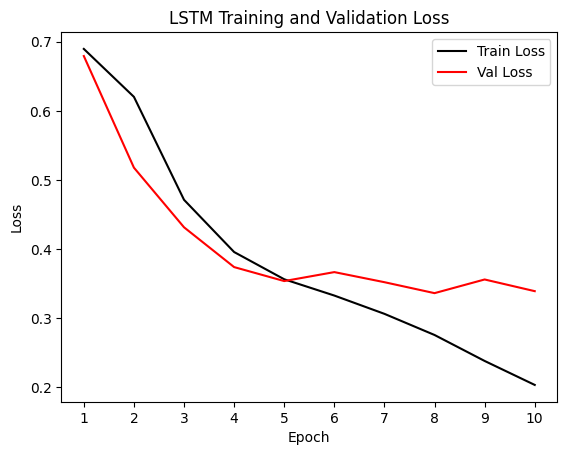

In [53]:
num_epochs = 10
learning_rate = 0.008
train_losses, val_losses = train(lstm_model, train_dataloader, val_dataloader, n_epochs=num_epochs, learning_rate=learning_rate)

epochs = range(1, num_epochs+1)
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss", c="black")
plt.plot(epochs, val_losses, label="Val Loss", c="red")

plt.xticks(range(1, num_epochs+1)) # every epoch
plt.title("LSTM Training and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

## Inference/Evaluation Loop

In [54]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [55]:
def test(lstm, test_data, n_batch_size=1024):
  # Loss function
  criterion = nn.CrossEntropyLoss()

  # Set metrics
  test_loss_tracking = 0
  test_accuracy = 0

  all_preds = []
  all_targets = []

  print(f"Testing on a dataset with n = {len(test_data)}.")
  lstm.eval()

  with torch.no_grad():
    for batch in test_data:
      # Get test batch
      X_test_batch, y_test_batch = batch

      # Reshape data
      X_test_batch = X_test_batch.permute(1, 0).to(device)
      y_test_batch = y_test_batch.to(device)

      # Preds
      preds = lstm(X_test_batch)
      pred_labels = preds.argmax(dim=1)

      # Test loss
      test_loss = criterion(preds, y_test_batch)

      # Accuracy
      accuracy = (pred_labels == y_test_batch).float().mean()
      test_accuracy += accuracy

      # Append
      all_targets.append(y_test_batch.cpu().numpy())
      all_preds.append(pred_labels.cpu().numpy())

      test_loss_tracking += test_loss.item()

    all_targets = np.concatenate(all_targets)
    all_preds = np.concatenate(all_preds)

    overall_test_loss = test_loss_tracking / len(test_data)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    test_accuracy = test_accuracy / len(test_data)
    print("The test loss is {0:.2f}.".format(overall_test_loss))
    print("The test accuracy is {0:.2f}.".format(test_accuracy*100))
    print("The precision score is {0:.2f}.".format(precision))
    print("The recall score is {0:.2f}.".format(recall))
    print("The F1 score is {0:.2f}.".format(f1))

    cm = confusion_matrix(all_targets, all_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

    return all_preds, all_targets

Testing on a dataset with n = 10.
The test loss is 0.34.
The test accuracy is 85.91.
The precision score is 0.86.
The recall score is 0.86.
The F1 score is 0.86.


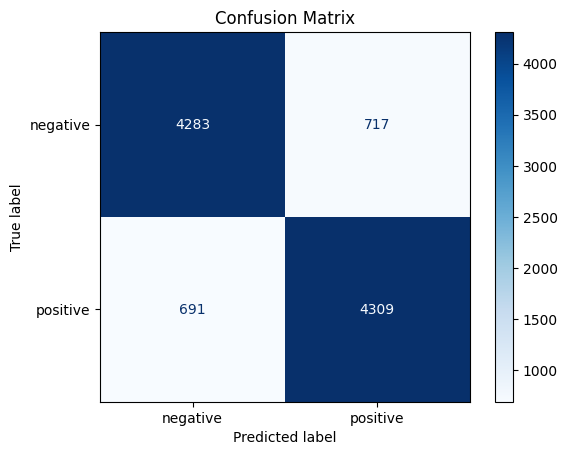

In [56]:
preds, targets = test(lstm_model, test_dataloader)

In [62]:
# Get incorrect predictions and true predictions, print out examples of both.
incorrect_predictions_indices = np.where(preds != targets)[0]
wrong_predictions = preds[incorrect_predictions_indices]

correct_predictions_indices = np.where(preds == targets)[0]
correct_predictions = preds[correct_predictions_indices]

# True labels
true_labels_wrong_predictions = targets[incorrect_predictions_indices]
true_labels_correct_predictions = targets[correct_predictions_indices]

In [58]:
# Perform a split on the text reviews, following the same random split.
X_train_text, X_test_text, y_train_label, y_test_label = train_test_split(text_reviews,
                                                                          text_sentiments,
                                                                          test_size=0.2,
                                                                          train_size=0.8,
                                                                          shuffle=True,
                                                                          random_state=random_seed)

incorr_test_texts = X_test_text.iloc[incorrect_predictions_indices].reset_index(drop=True)
corr_test_texts = X_test_text.iloc[correct_predictions_indices].reset_index(drop=True)
incorr_test_labels = y_test_label.iloc[incorrect_predictions_indices].reset_index(drop=True)
corr_test_labels = y_test_label.iloc[correct_predictions_indices].reset_index(drop=True)
# Print corresponding text, predictions, and true labels
print("------- Incorrect predictions ------\n")
incorr_pred = wrong_predictions[0]
if incorr_pred == 0:
  incorr_pred = "negative"
else:
  incorr_pred = "positive"
incorr_true_label = incorr_test_labels[0]
print(f"An example of text that was predicted {incorr_pred} but was actually {incorr_true_label}.")
print(incorr_test_texts[0])
print("\n")

print("------- Correct predictions ------\n")
corr_pred = correct_predictions[0]
if corr_pred == 0:
  corr_pred = "negative"
else:
  corr_pred = "positive"
corr_true_label = corr_test_labels[0]
print(f"An example of text that was predicted {corr_pred} and was actually {corr_true_label}.")
print(corr_test_texts[0])


------- Incorrect predictions ------

An example of text that was predicted positive but was actually positive.
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrib

## Evaluate Implemented Model

In [59]:
# Train
num_epochs = 10
embed_dim= 100
learning_rate = 0.008

lstm_model_implemented = LongShortTermMemory(input_size=embed_dim, embedding_matrix_vocab=embedding_matrix_vocab, hidden_size=256, output_size=2).to(device)


train_losses, val_losses = train(lstm_model_implemented, train_dataloader, val_dataloader, n_epochs=num_epochs, learning_rate=learning_rate)

Training on a dataset with n = 32000.
Validating on a dataset with n = 8000
The loss at epoch 0 is 0.71.
The validation loss at epoch 0 is 0.69
The validation accuracy at epoch 0 is 51.40
The loss at epoch 1 is 0.69.
The validation loss at epoch 1 is 0.69
The validation accuracy at epoch 1 is 51.70
The loss at epoch 2 is 0.69.
The validation loss at epoch 2 is 0.67
The validation accuracy at epoch 2 is 54.93
The loss at epoch 3 is 0.61.
The validation loss at epoch 3 is 0.49
The validation accuracy at epoch 3 is 77.39
The loss at epoch 4 is 0.42.
The validation loss at epoch 4 is 0.38
The validation accuracy at epoch 4 is 83.59
The loss at epoch 5 is 0.36.
The validation loss at epoch 5 is 0.34
The validation accuracy at epoch 5 is 85.19
The loss at epoch 6 is 0.32.
The validation loss at epoch 6 is 0.34
The validation accuracy at epoch 6 is 85.59
The loss at epoch 7 is 0.28.
The validation loss at epoch 7 is 0.30
The validation accuracy at epoch 7 is 87.24
The loss at epoch 8 is 0.25.

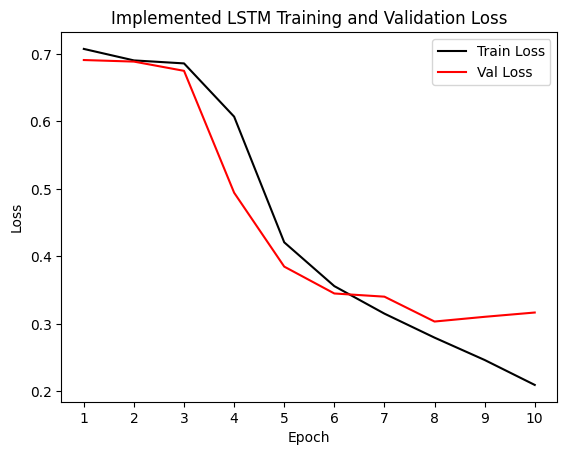

In [60]:
epochs = range(1, num_epochs+1)
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss", c="black")
plt.plot(epochs, val_losses, label="Val Loss", c="red")

plt.xticks(range(1, num_epochs+1)) # every epoch
plt.title("Implemented LSTM Training and Validation Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

Testing on a dataset with n = 10.
The test loss is 0.31.
The test accuracy is 87.06.
The precision score is 0.85.
The recall score is 0.90.
The F1 score is 0.87.


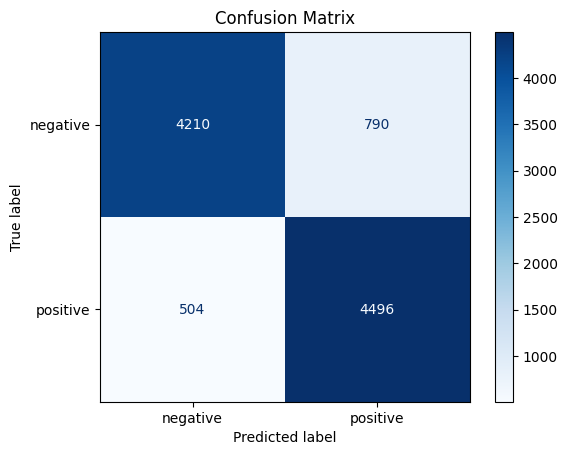

In [61]:
preds, targets = test(lstm_model_implemented, test_dataloader)